<a href="https://colab.research.google.com/github/sangramshitole07/AML/blob/main/AML_Linear_regression_Using_csvData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
data ={
    "Study_hours":[2,3,4,5,6,7,8,9],
    "Attendance":[60,65,70,75,80,85,90,95],
    "Assignment_score":[50,55,58,65,70,74,80,88],
    "Final_Marks":[42,48,54,61,67,73,81,89]
}
df = pd.DataFrame(data)

# Add 'Weekly_hours' column
df['Weekly_hours'] = df['Study_hours'] * 7

# Save the DataFrame to a new CSV file
csv_file_path_new = 'student_data_with_weekly_hours.csv'
df.to_csv(csv_file_path_new, index=False)

print(f"DataFrame with Weekly_hours saved to {csv_file_path_new}")

DataFrame with Weekly_hours saved to student_data_with_weekly_hours.csv


Now, let's load the data from the CSV file back into a new DataFrame and display its first 5 rows.

In [ ]:
import pandas as pd
df_from_csv = pd.read_csv(csv_file_path_new)
display(df_from_csv.head())

,Study_hours,Attendance,Assignment_score,Final_Marks,Weekly_hours
0,2,60,50,42,14
1,3,65,55,48,21
2,4,70,58,54,28
3,5,75,65,61,35
4,6,80,70,67,42


In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_from_csv.drop('Final_Marks', axis=1)
y = df_from_csv['Final_Marks']

# Perform train-test split (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:

from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
print("Intercept ",model.intercept_)
print("Coefficient ",model.coef_)
print("Slope ",model.coef_)

Intercept  -5.246666666666684
Coefficient  [0.05093333 0.25466667 0.53333333 0.35653333]
Slope  [0.05093333 0.25466667 0.53333333 0.35653333]


In [ ]:
cofficient_table=pd.DataFrame({
    "Features":X.columns,
    "Coefficient":model.coef_
})
cofficient_table

,Features,Coefficient
0,Study_hours,0.050933
1,Attendance,0.254667
2,Assignment_score,0.533333
3,Weekly_hours,0.356533


In [ ]:
y_test

,Final_Marks
1,48
5,73


In [ ]:
y_pred=model.predict(X_test)
y_pred

array([48.28      , 73.69333333])

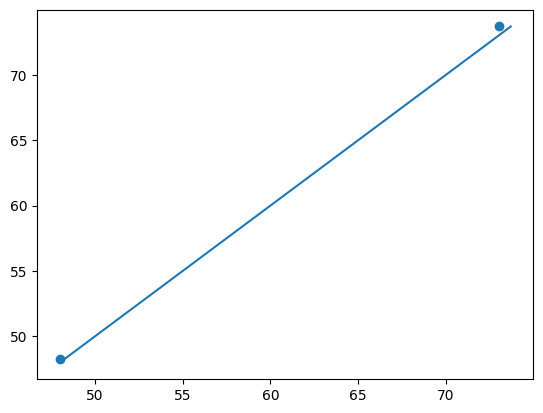

In [ ]:
from scipy.optimize import minimize
import matplotlib.pyplot as plt
minimum=min(y_test.min(),y_pred.min())
maximum=max(y_test.max(),y_pred.max())
plt.plot([minimum,maximum],[minimum,maximum])
plt.scatter(y_test,y_pred)

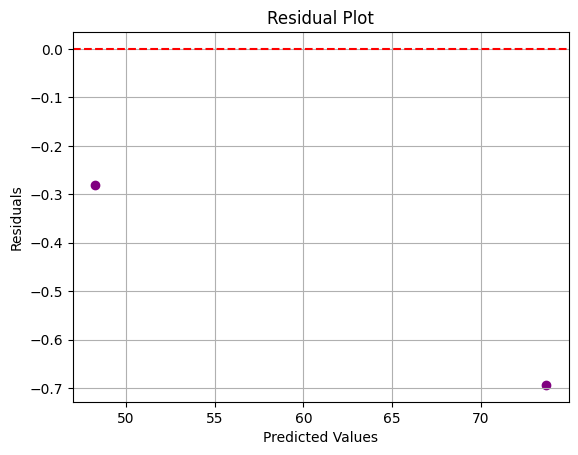

In [ ]:
from matplotlib import lines
residual =y_test - y_pred
plt.scatter(y_pred,residual,color='purple')
plt.axhline(y=0,color='red',linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()